In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import os
# import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
from tqdm import tqdm


In [3]:
# Set directories
base_dir = "/Users/smb-uh/"
data_dir = base_dir + "UHM_Ocean_BGC_Group Dropbox/Datasets/"
home_dir = base_dir + "UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/Work/"
manuscript_dir = home_dir + "Manuscripts/2025_01 BGC Argo Plus Dataset Creation/"
manuscript_figs = manuscript_dir + "Figures/"
group_manuscript_figs = manuscript_dir + "Dataset paper group folder/Figures/" 
argo_path = data_dir + "Data_Products/BGC_ARGO_GLOBAL/2025_01_24/Sprof/"
processed_path = argo_path + "../processed/"
plot_ver = 'v_202608'

## Bottom Hook Example

In [4]:

# file = '6901182_Sprof_flags_mode_only.nc'
# file = '6901181_Sprof_flags_mode_only.nc'
file = '5901737_Sprof_flags_mode_only.nc'

argo_n = xr.load_dataset(processed_path+file)
argo_n


<xarray.Dataset> Size: 4MB
Dimensions:                         (N_PROF: 33, N_PARAM: 4, N_CALIB: 1,
                                     N_LEVELS: 968)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/82)
    DATA_TYPE                       object 8B b'Argo synthetic profile       ...
    FORMAT_VERSION                  object 8B b'1.0 '
    HANDBOOK_VERSION                object 8B b'1.2 '
    REFERENCE_DATE_TIME             object 8B b'19500101000000'
    DATE_CREATION                   object 8B b'20241119201539'
    DATE_UPDATE                     object 8B b'20241119201539'
    ...                              ...
    DOXY_ADJUSTED_QC_n_3_removed    int64 8B 0
    DOXY_ADJUSTED_QC_n_4_removed    int64 8B 18144
    PRES_profile_mode               (N_PROF) float64 264B 2.0 2.0 ... 2.0 2.0
    TEMP_profile_mode               (N_PROF) float64 264B 2.0 2.0 ... 2.0 2.0
    PSAL_profile_mode               (N_PROF) float64 264B 2.0 2.0 ... 2.0 2.0
    DOXY_profile_mode               (N_PROF) float64 264B 2.0 2.0 ... 2.0 2.0
Attributes:
    title:                Argo float vertical profile
    institution:          AOML
    source:               Argo float
    history:              2024-11-19T20:15:39Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

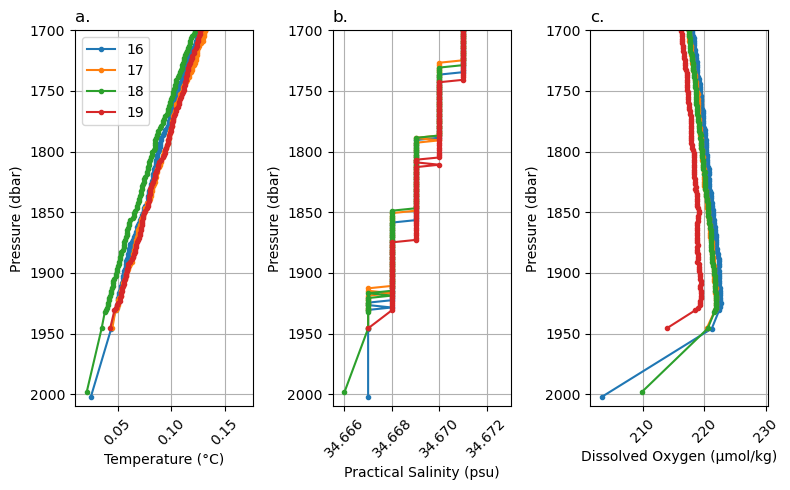

In [15]:
profile_range = np.arange(16, 20)
pressure_lims = [2010, 1700]

# plot profiles and time series
variables = ['TEMP', 'PSAL', 'DOXY']
var_full_names = {'TEMP': 'Temperature', 'PSAL': 'Practical Salinity', 'DOXY': 'Dissolved Oxygen'}
units = {'TEMP': '°C', 'PSAL': 'psu', 'DOXY': 'µmol/kg'}
var_type = '_ADJUSTED_BGCArgoPlus'
fig = plt.figure(figsize=(8, 5))


filename = 'Bottom_Hook_Example_Float_' + file.split('_')[0] + '_' + plot_ver
plot_count = 0
for i, var in enumerate(variables):
    plot_count += 1
    min_val = 1000
    max_val = -1000
    ax1 = plt.subplot(1, 3, i+1)
    for prof in profile_range:
        # remove nans before plotting:
        data_p = argo_n[var + var_type].isel(N_PROF=prof)
        pres = argo_n['PRES' + var_type].isel(N_PROF=prof)
        msk = np.isfinite(data_p) & np.isfinite(pres)
        ax1.plot(data_p[msk], pres[msk], marker='.', label=f'{prof}')
        min_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
        max_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
        if min_val_n < min_val:
            min_val = min_val_n
        if max_val_n > max_val:
            max_val = max_val_n
    ax1.invert_yaxis()
    # ax1.set_title(f'{var_full_names[var]}')
    if plot_count==1:
            ax1.set_title('a.', loc='left')
    elif plot_count==2:
        ax1.set_title('b.', loc='left')
    elif plot_count==3: 
        ax1.set_title('c.', loc='left')
    ax1.set_xlabel(f'{var_full_names[var]} ({units[var]})')
    ax1.set_ylabel('Pressure (dbar)')
    ax1.ticklabel_format(useOffset=False, style='plain')
    ax1.tick_params(axis='x', labelrotation=45)
    ax1.grid()
    # min_val = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
    # max_val = data_p.where(pres>=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
    max_min = [min_val - 0.1*(max_val - min_val), max_val + 0.4*(max_val - min_val)]
    ax1.set_ylim(pressure_lims)
    ax1.set_xlim(max_min)
    # if var == 'DOXY':
    #     ax1.set_xlim(278, 300)
    # elif var == 'PSAL':
    #     ax1.set_xlim(min_val, max_val)
    # elif var == 'TEMP':
    #     ax1.set_xlim(min_val, max_val)
    if plot_count==1:
        ax1.legend()

    # ax2 = plt.subplot(2, 3, i+4)
    # times = argo_n['JULD'].isel(N_PROF=profile_range)
    # mean_values = argo_n[var].isel(N_PROF=profile_range).mean(dim='N_LEVELS')
    # ax2.plot(times, mean_values, marker='o', linestyle='-')
    # ax2.set_title(f'{var} Time Series (Mean over Profiles)')
    # ax2.set_xlabel('Time (Julian Days)')
    # ax2.set_ylabel(f'Mean {var}')
    # ax2.grid()
plt.tight_layout()
plt.savefig(manuscript_figs + filename + '.png', dpi=300)


In [14]:
manuscript_figs

'/Users/smb-uh/UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/Work/Manuscripts/2025_01 BGC Argo Plus Dataset Creation/Figures/'

## Surface measurement example

In [6]:

# file = '6901182_Sprof_flags_mode_only.nc'
file = '6901774_Sprof_flags_mode_only.nc'

argo_n = xr.load_dataset(processed_path+file)
argo_n


<xarray.Dataset> Size: 131MB
Dimensions:                                       (N_PROF: 218, N_PARAM: 12,
                                                   N_CALIB: 1, N_LEVELS: 1400)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/178)
    DATA_TYPE                                     object 8B b'Argo synthetic ...
    FORMAT_VERSION                                object 8B b'1.0 '
    HANDBOOK_VERSION                              object 8B b'1.2 '
    REFERENCE_DATE_TIME                           object 8B b'19500101000000'
    DATE_CREATION                                 object 8B b'20241224123007'
    DATE_UPDATE                                   object 8B b'20241224123007'
    ...                                            ...
    DOWN_IRRADIANCE490_profile_mode               (N_PROF) float64 2kB 0.0 .....
    DOWNWELLING_PAR_profile_mode                  (N_PROF) float64 2kB 0.0 .....
    CHLA_profile_mode                             (N_PROF) float64 2kB 1.0 .....
    CHLA_FLUORESCENCE_profile_mode                (N_PROF) float64 2kB 0.0 .....
    BBP700_profile_mode                           (N_PROF) float64 2kB 1.0 .....
    CDOM_profile_mode                             (N_PROF) float64 2kB 0.0 .....
Attributes:
    title:                Argo float vertical profile
    institution:          CORIOLIS
    source:               Argo float
    history:              2024-12-24T12:30:07Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

In [9]:
argo_n['PSAL_ADJUSTED_BGCArgoPlus']

<xarray.DataArray 'PSAL_ADJUSTED_BGCArgoPlus' (N_PROF: 218, N_LEVELS: 1400)> Size: 1MB
array([[36.9668  , 36.9668  , 36.964798, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [36.97481 , 36.97481 , 36.97481 , ...,       nan,       nan,
              nan],
       ...,
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan]], dtype=float32)
Dimensions without coordinates: N_PROF, N_LEVELS
Attributes:
    long_name:       Practical salinity
    standard_name:   sea_water_salinity
    units:           psu
    valid_min:       2.0
    valid_max:       41.0
    C_format:        %.4f
    FORTRAN_format:  F.4
    resolution:      1e-04

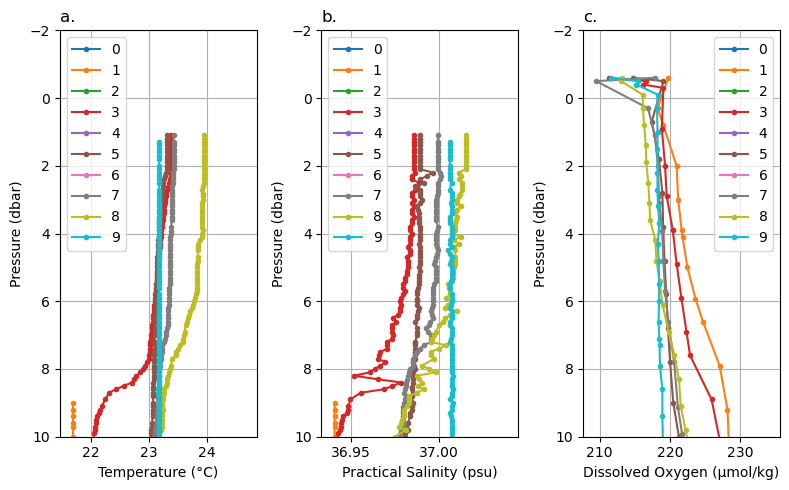

In [14]:
profile_range = np.arange(0, 10)
pressure_lims = [10, -2]

# plot profiles and time series
variables = ['TEMP', 'PSAL', 'DOXY']
var_full_names = {'TEMP': 'Temperature', 'PSAL': 'Practical Salinity', 'DOXY': 'Dissolved Oxygen'}
units = {'TEMP': '°C', 'PSAL': 'psu', 'DOXY': 'µmol/kg'}
var_type = '_ADJUSTED_BGCArgoPlus'
fig = plt.figure(figsize=(8, 5))


filename = 'Surface_Obs_Example_Float_' + file.split('_')[0] + '_' + plot_ver
plot_count = 0
for i, var in enumerate(variables):
    plot_count += 1
    min_val = 1000
    max_val = -1000
    ax1 = plt.subplot(1, 3, i+1)
    for prof in profile_range:
        # remove nans before plotting:
        data_p = argo_n[var + var_type].isel(N_PROF=prof)
        pres = argo_n['PRES' + var_type].isel(N_PROF=prof)
        msk = np.isfinite(data_p) & np.isfinite(pres)
        ax1.plot(data_p[msk], pres[msk], marker='.', label=f'{prof}')
        min_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
        max_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
        if min_val_n < min_val:
            min_val = min_val_n
        if max_val_n > max_val:
            max_val = max_val_n
    ax1.invert_yaxis()
    # ax1.set_title(f'{var_full_names[var]}')
    if plot_count==1:
        ax1.set_title('a.', loc='left')
    elif plot_count==2:
        ax1.set_title('b.', loc='left')
    elif plot_count==3: 
        ax1.set_title('c.', loc='left')
    ax1.set_xlabel(f'{var_full_names[var]} ({units[var]})')
    ax1.set_ylabel('Pressure (dbar)')
    ax1.grid()
    # min_val = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
    # max_val = data_p.where(pres>=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
    max_min = [min_val - 0.1*(max_val - min_val), max_val + 0.4*(max_val - min_val)]
    ax1.set_ylim(pressure_lims)
    ax1.set_xlim(max_min)
    # if var == 'DOXY':
    #     ax1.set_xlim(278, 300)
    # elif var == 'PSAL':
    #     ax1.set_xlim(min_val, max_val)
    # elif var == 'TEMP':
    #     ax1.set_xlim(min_val, max_val)
    ax1.legend()

    # ax2 = plt.subplot(2, 3, i+4)
    # times = argo_n['JULD'].isel(N_PROF=profile_range)
    # mean_values = argo_n[var].isel(N_PROF=profile_range).mean(dim='N_LEVELS')
    # ax2.plot(times, mean_values, marker='o', linestyle='-')
    # ax2.set_title(f'{var} Time Series (Mean over Profiles)')
    # ax2.set_xlabel('Time (Julian Days)')
    # ax2.set_ylabel(f'Mean {var}')
    # ax2.grid()
plt.tight_layout()
plt.savefig(manuscript_figs + filename + '.png', dpi=300)


## ML "GOO" example

In [ ]:
# wmo = '5905372'



<xarray.Dataset> Size: 13MB
Dimensions:                                      (N_PROF: 71, N_PARAM: 9,
                                                  N_CALIB: 1, N_LEVELS: 559)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/142)
    DATA_TYPE                                    object 8B b'Argo synthetic p...
    FORMAT_VERSION                               object 8B b'1.0 '
    HANDBOOK_VERSION                             object 8B b'1.2 '
    REFERENCE_DATE_TIME                          object 8B b'19500101000000'
    DATE_CREATION                                object 8B b'20241226045109'
    DATE_UPDATE                                  object 8B b'20241226045109'
    ...                                           ...
    DOXY_profile_mode                            (N_PROF) float64 568B 2.0 .....
    CHLA_profile_mode                            (N_PROF) float64 568B 1.0 .....
    CHLA_FLUORESCENCE_profile_mode               (N_PROF) float64 568B 1.0 .....
    BBP700_profile_mode                          (N_PROF) float64 568B 1.0 .....
    PH_IN_SITU_TOTAL_profile_mode                (N_PROF) float64 568B 2.0 .....
    NITRATE_profile_mode                         (N_PROF) float64 568B 2.0 .....
Attributes:
    title:                Argo float vertical profile
    institution:          AOML
    source:               Argo float
    history:              2024-12-26T04:51:09Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

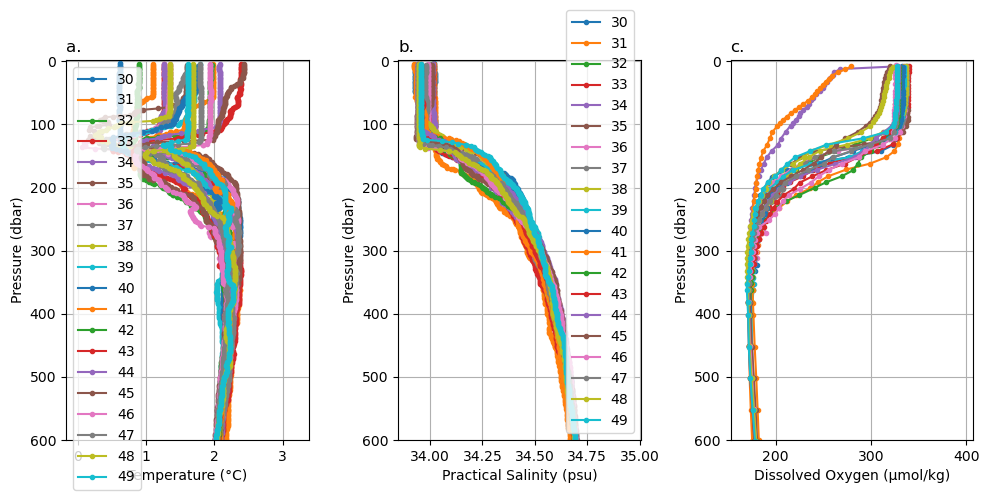

In [ ]:
wmo = '5906554'

# file = '6901182_Sprof_flags_mode_only.nc'
file = wmo+'_Sprof_flags_mode_only.nc'

argo_n = xr.load_dataset(processed_path+file)
argo_n

profile_range = np.arange(30, 50)
pressure_lims = [600, -2]

# plot profiles and time series
variables = ['TEMP', 'PSAL', 'DOXY']
var_full_names = {'TEMP': 'Temperature', 'PSAL': 'Practical Salinity', 'DOXY': 'Dissolved Oxygen'}
units = {'TEMP': '°C', 'PSAL': 'psu', 'DOXY': 'µmol/kg'}
var_type = '_ADJUSTED_BGCArgoPlus'
fig = plt.figure(figsize=(10, 5))


filename = 'ML_Goo_Obs_Example_Float_' + file.split('_')[0] + '_' + plot_ver
plot_count = 0
for i, var in enumerate(variables):
    plot_count += 1
    min_val = 1000
    max_val = -1000
    ax1 = plt.subplot(1, 3, i+1)
    for prof in profile_range:
        # remove nans before plotting:
        data_p = argo_n[var + var_type].isel(N_PROF=prof)
        pres = argo_n['PRES' + var_type].isel(N_PROF=prof)
        msk = np.isfinite(data_p) & np.isfinite(pres)
        ax1.plot(data_p[msk], pres[msk], marker='.', label=f'{prof}')
        min_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
        max_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
        if min_val_n < min_val:
            min_val = min_val_n
        if max_val_n > max_val:
            max_val = max_val_n
    ax1.invert_yaxis()
    if plot_count==1:
        ax1.set_title('a.', loc='left')
    elif plot_count==2:
        ax1.set_title('b.', loc='left')
    elif plot_count==3: 
        ax1.set_title('c.', loc='left')
    ax1.set_xlabel(f'{var_full_names[var]} ({units[var]})')
    ax1.set_ylabel('Pressure (dbar)')
    ax1.grid()
    # min_val = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
    # max_val = data_p.where(pres>=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
    max_min = [min_val - 0.1*(max_val - min_val), max_val + 0.4*(max_val - min_val)]
    ax1.set_ylim(pressure_lims)
    ax1.set_xlim(max_min)
    # if var == 'DOXY':
    #     ax1.set_xlim(278, 300)
    # elif var == 'PSAL':
    #     ax1.set_xlim(min_val, max_val)
    # elif var == 'TEMP':
    #     ax1.set_xlim(min_val, max_val)
    if plot_count!=3:
        ax1.legend()

    # ax2 = plt.subplot(2, 3, i+4)
    # times = argo_n['JULD'].isel(N_PROF=profile_range)
    # mean_values = argo_n[var].isel(N_PROF=profile_range).mean(dim='N_LEVELS')
    # ax2.plot(times, mean_values, marker='o', linestyle='-')
    # ax2.set_title(f'{var} Time Series (Mean over Profiles)')
    # ax2.set_xlabel('Time (Julian Days)')
    # ax2.set_ylabel(f'Mean {var}')
    # ax2.grid()
plt.tight_layout()
plt.savefig(group_manuscript_figs + filename + '.png', dpi=300)


In [144]:
# looking for ascent timing information -  ("MTIME" or "NB_SAMPLE_CTD").
wmo = '5906554'
goo_dir = home_dir + 'Projects/2023_10 UHM_BGC_float_processing/interim_data/' + wmo + '_goo_investigation/'

prof_n = xr.load_dataset(goo_dir + wmo + '_prof.nc')
prof_n

single_prof = xr.load_dataset(goo_dir + 'D' + wmo + '_033.nc')
single_prof

# rtraj = xr.load_dataset(goo_dir + wmo + '_Rtraj.nc')
# for var in rtraj.keys():
#     print(var, rtraj[var].long_name)

<xarray.Dataset> Size: 97kB
Dimensions:                       (N_PROF: 2, N_PARAM: 4, N_LEVELS: 498,
                                   N_CALIB: 1, N_HISTORY: 4)
Dimensions without coordinates: N_PROF, N_PARAM, N_LEVELS, N_CALIB, N_HISTORY
Data variables: (12/67)
    DATA_TYPE                     object 8B b'Argo profile    '
    FORMAT_VERSION                object 8B b'3.1 '
    HANDBOOK_VERSION              object 8B b'1.2 '
    REFERENCE_DATE_TIME           object 8B b'19500101000000'
    DATE_CREATION                 object 8B b'20231208080142'
    DATE_UPDATE                   object 8B b'20240425094238'
    ...                            ...
    HISTORY_ACTION                (N_HISTORY, N_PROF) object 64B b'  IP' ... ...
    HISTORY_PARAMETER             (N_HISTORY, N_PROF) object 64B b'          ...
    HISTORY_START_PRES            (N_HISTORY, N_PROF) float32 32B nan ... nan
    HISTORY_STOP_PRES             (N_HISTORY, N_PROF) float32 32B nan ... nan
    HISTORY_PREVIOUS_VALUE        (N_HISTORY, N_PROF) float32 32B nan ... nan
    HISTORY_QCTEST                (N_HISTORY, N_PROF) object 64B b'          ...
Attributes:
    title:                  Argo float vertical profile
    institution:            AOML
    source:                 Argo float
    history:                2023-12-08T08:01:42Z creation
    references:             http://www.argodatamgt.org/Documentation
    comment:                free text
    user_manual_version:    3.2
    Conventions:            Argo-3.2 CF-1.6
    featureType:            trajectoryProfile
    comment_dmqc_operator:  PRIMARY | https://orcid.org/0000-0001-7324-3159 |...

(300.0, 0.0)

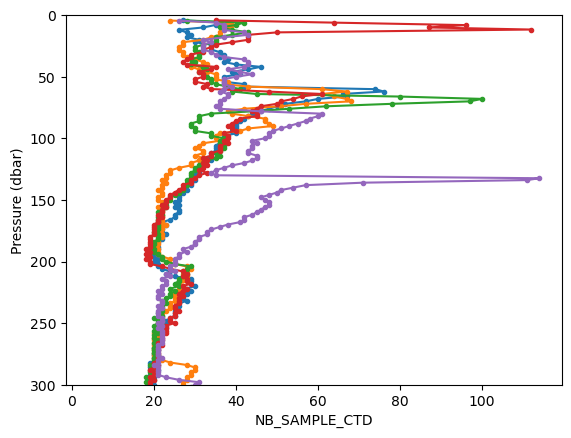

In [154]:
for cyc in range(32,37):
    single_prof = xr.load_dataset(goo_dir + 'D' + wmo + f'_{cyc:03d}.nc')

    plt.plot(single_prof['NB_SAMPLE_CTD'][0], single_prof['PRES'][0], marker='.')
    plt.ylabel('Pressure (dbar)')
    plt.xlabel('NB_SAMPLE_CTD')
    plt.gca().invert_yaxis()

plt.ylim(300,0)

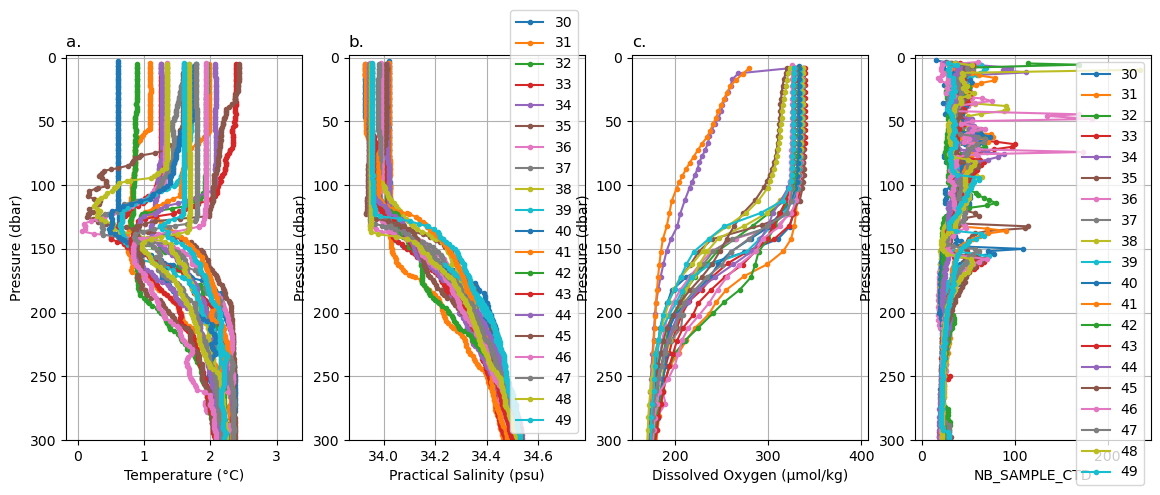

In [162]:
wmo = '5906554'

# file = '6901182_Sprof_flags_mode_only.nc'
file = wmo+'_Sprof_flags_mode_only.nc'

argo_n = xr.load_dataset(processed_path+file)
argo_n

profile_range = np.arange(30, 50)
pressure_lims = [300, -2]

# plot profiles and time series
variables = ['TEMP', 'PSAL', 'DOXY']
var_full_names = {'TEMP': 'Temperature', 'PSAL': 'Practical Salinity', 'DOXY': 'Dissolved Oxygen'}
units = {'TEMP': '°C', 'PSAL': 'psu', 'DOXY': 'µmol/kg'}
var_type = '_ADJUSTED_BGCArgoPlus'
fig = plt.figure(figsize=(14, 5))


filename = 'ML_Goo_Obs_Example_Float_' + file.split('_')[0] + '_' + plot_ver
plot_count = 0
for i, var in enumerate(variables):
    plot_count += 1
    min_val = 1000
    max_val = -1000
    ax1 = plt.subplot(1, 4, i+1)
    for prof in profile_range:
        # remove nans before plotting:
        data_p = argo_n[var + var_type].isel(N_PROF=prof)
        pres = argo_n['PRES' + var_type].isel(N_PROF=prof)
        msk = np.isfinite(data_p) & np.isfinite(pres)
        ax1.plot(data_p[msk], pres[msk], marker='.', label=f'{prof}')
        min_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
        max_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
        if min_val_n < min_val:
            min_val = min_val_n
        if max_val_n > max_val:
            max_val = max_val_n
    ax1.invert_yaxis()
    if plot_count==1:
        ax1.set_title('a.', loc='left')
    elif plot_count==2:
        ax1.set_title('b.', loc='left')
    elif plot_count==3: 
        ax1.set_title('c.', loc='left')
    ax1.set_xlabel(f'{var_full_names[var]} ({units[var]})')
    ax1.set_ylabel('Pressure (dbar)')
    ax1.grid()
    # min_val = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
    # max_val = data_p.where(pres>=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
    max_min = [min_val - 0.1*(max_val - min_val), max_val + 0.4*(max_val - min_val)]
    ax1.set_ylim(pressure_lims)
    ax1.set_xlim(max_min)
    # if var == 'DOXY':
    #     ax1.set_xlim(278, 300)
    # elif var == 'PSAL':
    #     ax1.set_xlim(min_val, max_val)
    # elif var == 'TEMP':
    #     ax1.set_xlim(min_val, max_val)
    if plot_count==2:
        ax1.legend()

ax1 = plt.subplot(1, 4, 4)
for prof in profile_range:
    single_prof = xr.load_dataset(goo_dir + 'D' + wmo + f'_{prof+1:03d}.nc')
    plt.plot(single_prof['NB_SAMPLE_CTD'][0], single_prof['PRES'][0], marker='.', label=f'{prof}')
plt.gca().invert_yaxis()
plt.xlabel('NB_SAMPLE_CTD')
plt.ylabel('Pressure (dbar)')
plt.grid()
ax1.set_ylim(pressure_lims)
ax1.legend()



In [72]:
sd = xr.load_dataset(goo_dir + 'SD' + wmo + '_011.nc')
for var in sd.keys():
    print(var, sd[var].long_name)

DATA_TYPE Data type
FORMAT_VERSION File format version
HANDBOOK_VERSION Data handbook version
REFERENCE_DATE_TIME Date of reference for Julian days
DATE_CREATION Date of file creation
DATE_UPDATE Date of update of this file
PLATFORM_NUMBER Float unique identifier
PROJECT_NAME Name of the project
PI_NAME Name of the principal investigator
STATION_PARAMETERS List of available parameters for the station
CYCLE_NUMBER Float cycle number
DIRECTION Direction of the station profiles
DATA_CENTRE Data centre in charge of float data processing
PARAMETER_DATA_MODE Delayed mode or real time data
PLATFORM_TYPE Type of float
FLOAT_SERIAL_NO Serial number of the float
FIRMWARE_VERSION Instrument firmware version
WMO_INST_TYPE Coded instrument type
JULD Julian day (UTC) of the station relative to REFERENCE_DATE_TIME
JULD_QC Quality on date and time
JULD_LOCATION Julian day (UTC) of the location relative to REFERENCE_DATE_TIME
LATITUDE Latitude of the station, best estimate
LONGITUDE Longitude of the st

In [74]:
dtraj = xr.load_dataset(goo_dir + wmo + '_Dtraj.nc')
for var in dtraj.keys():
    print(var, ',',dtraj[var].long_name)

DATA_TYPE , Data type
FORMAT_VERSION , File format version
HANDBOOK_VERSION , Data handbook version
REFERENCE_DATE_TIME , Date of reference for Julian days
DATE_CREATION , Date of file creation
DATE_UPDATE , Date of update of this file
PLATFORM_NUMBER , Float unique identifier
PROJECT_NAME , Name of the project
PI_NAME , Name of the principal investigator
TRAJECTORY_PARAMETERS , List of available parameters
DATA_CENTRE , Data centre in charge of float data processing
DATA_STATE_INDICATOR , Degree of processing the data have passed through
PLATFORM_TYPE , Type of float
FLOAT_SERIAL_NO , Serial number of the float
FIRMWARE_VERSION , Instrument firmware version
WMO_INST_TYPE , Coded instrument type
POSITIONING_SYSTEM , Positioning system
JULD , Julian day (UTC) of each measurement relative to REFERENCE_DATE_TIME
JULD_STATUS , Status of the date and time
JULD_QC , Quality on date and time
JULD_ADJUSTED , Adjusted julian day (UTC) of each measurement relative to REFERENCE_DATE_TIME
JULD_ADJ

In [132]:
dtraj


<xarray.Dataset> Size: 20MB
Dimensions:                              (N_PARAM: 13, N_MEASUREMENT: 39286,
                                          N_CYCLE: 157, N_CALIB_PARAM: 1,
                                          N_CALIB_JULD: 1, N_HISTORY: 25)
Dimensions without coordinates: N_PARAM, N_MEASUREMENT, N_CYCLE, N_CALIB_PARAM,
                                N_CALIB_JULD, N_HISTORY
Data variables: (12/145)
    DATA_TYPE                            object 8B b'Argo trajectory '
    FORMAT_VERSION                       object 8B b'3.2 '
    HANDBOOK_VERSION                     object 8B b'1.2 '
    REFERENCE_DATE_TIME                  object 8B b'19500101000000'
    DATE_CREATION                        object 8B b'20240423210255'
    DATE_UPDATE                          object 8B b'20250815210255'
    ...                                   ...
    HISTORY_PARAMETER                    (N_HISTORY) object 200B b'          ...
    HISTORY_PREVIOUS_VALUE               (N_HISTORY) float32 100B nan ... nan
    HISTORY_INDEX_DIMENSION              (N_HISTORY) object 200B nan nan ... nan
    HISTORY_START_INDEX                  (N_HISTORY) float64 200B nan ... nan
    HISTORY_STOP_INDEX                   (N_HISTORY) float64 200B nan ... nan
    HISTORY_QCTEST                       (N_HISTORY) object 200B b'0         ...
Attributes:
    title:                Argo float trajectory file
    institution:          AOML
    source:               Argo float
    history:              2024-04-23T21:02:55Z creation
    references:           http://www.argodatamgt.org/Documentation
    comment:              /comment_dmqc_operator: PRIMARY | https://orcid.org...
    user_manual_version:  3.41.1
    Conventions:          Argo-3.2 CF-1.6
    featureType:          trajectory

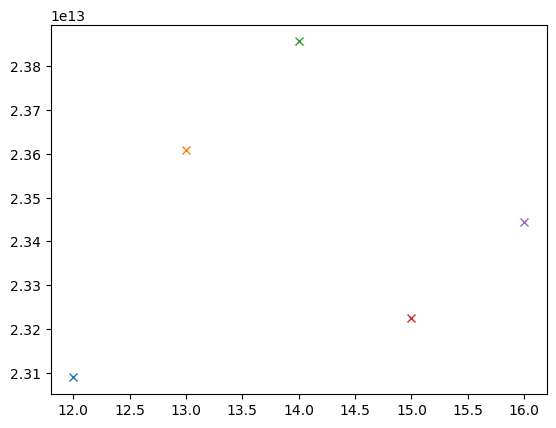

In [133]:
# print(dtraj['JULD_ASCENT_START'][11].values)
# print(dtraj['JULD_ASCENT_END'][11].values)
for n in range(12,17):
    time_diff = dtraj['JULD_ASCENT_END'][n].values - dtraj['JULD_ASCENT_START'][n].values
    plt.plot(dtraj['N_CYCLE'][n], time_diff, 'x')


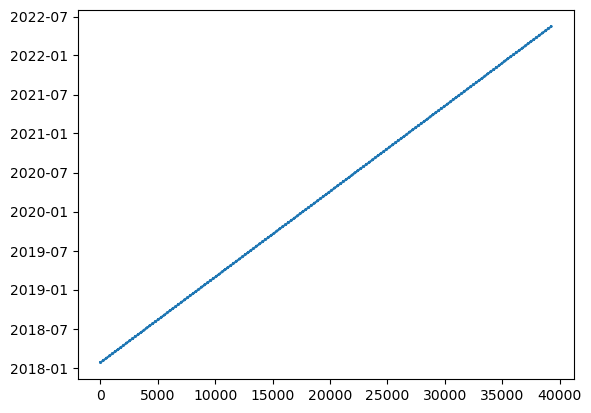

In [105]:
plt.plot(dtraj['JULD'])

In [79]:
tech = xr.load_dataset(goo_dir + wmo + '_tech.nc')
for var in tech.keys():
    print(var, ',',tech[var].long_name)

PLATFORM_NUMBER , Float unique identifier
DATA_TYPE , Data type
FORMAT_VERSION , File format version
HANDBOOK_VERSION , Data handbook version
DATA_CENTRE , Data centre in charge of float data processing
DATE_CREATION , Date of file creation
DATE_UPDATE , Date of update of this file
TECHNICAL_PARAMETER_NAME , Name of technical parameter
TECHNICAL_PARAMETER_VALUE , Value of technical parameter
CYCLE_NUMBER , Float cycle number


In [80]:
meta = xr.load_dataset(goo_dir + wmo + '_meta.nc')
for var in meta.keys():
    print(var, ',',meta[var].long_name)

DATA_TYPE , Data type
FORMAT_VERSION , File format version
HANDBOOK_VERSION , Data handbook version
DATE_CREATION , Date of file creation
DATE_UPDATE , Date of update of this file
PLATFORM_NUMBER , Float unique identifier
PTT , Transmission identifier (ARGOS, ORBCOMM, etc.)
TRANS_SYSTEM , Telecommunications system used
TRANS_SYSTEM_ID , Program identifier used by the transmission system
TRANS_FREQUENCY , Frequency of transmission from the float
POSITIONING_SYSTEM , Positioning system
PLATFORM_FAMILY , Category of instrument
PLATFORM_TYPE , Type of float
PLATFORM_MAKER , Name of the manufacturer
FIRMWARE_VERSION , Firmware version for the float
MANUAL_VERSION , Manual version for the float
FLOAT_SERIAL_NO , Serial number of the float
STANDARD_FORMAT_ID , Standard format number to describe the data format type for each float
DAC_FORMAT_ID , Format number used by the DAC to describe the data format type for each float
WMO_INST_TYPE , Coded instrument type
PROJECT_NAME , Program under whic

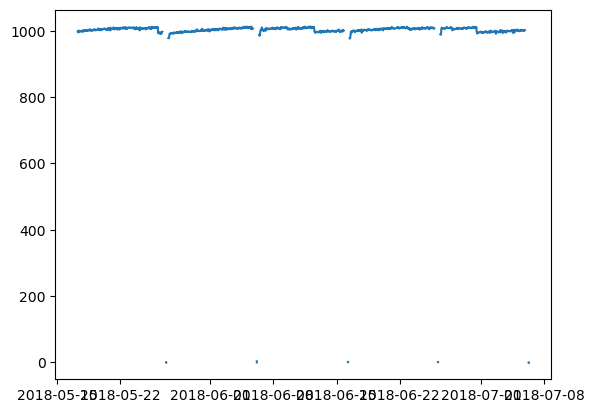

In [109]:
# ok, so the rtrajectory file seems to have individual times for each sample, not just each profile.
# so let's find the samples that correspond to profiles 12-16
time_index = rtraj['CYCLE_NUMBER'].isin(np.arange(13, 18))
plt.plot(rtraj['JULD'][time_index], rtraj['PRES'][time_index])

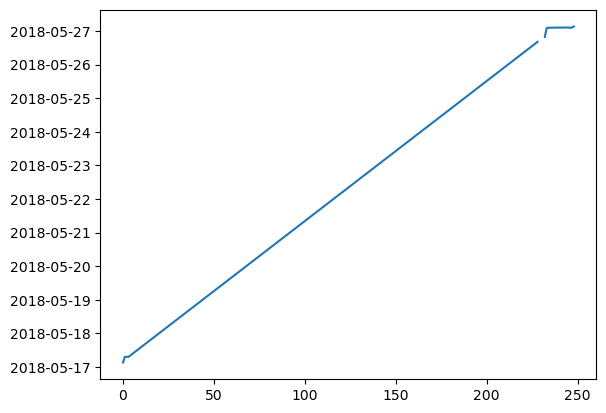

In [66]:
plt.plot(rtraj['JULD'][time_index])

In [46]:
for var in prof_n.keys():
    print(var, ',', prof_n[var].long_name)

DATA_TYPE , Data type
FORMAT_VERSION , File format version
HANDBOOK_VERSION , Data handbook version
REFERENCE_DATE_TIME , Date of reference for Julian days
DATE_CREATION , Date of file creation
DATE_UPDATE , Date of update of this file
PLATFORM_NUMBER , Float unique identifier
PROJECT_NAME , Name of the project
PI_NAME , Name of the principal investigator
STATION_PARAMETERS , List of available parameters for the station
CYCLE_NUMBER , Float cycle number
DIRECTION , Direction of the station profiles
DATA_CENTRE , Data centre in charge of float data processing
DC_REFERENCE , Station unique identifier in data centre
DATA_STATE_INDICATOR , Degree of processing the data have passed through
DATA_MODE , Delayed mode or real time data
PLATFORM_TYPE , Type of float
FLOAT_SERIAL_NO , Serial number of the float
FIRMWARE_VERSION , Instrument firmware version
WMO_INST_TYPE , Coded instrument type
JULD , Julian day (UTC) of the station relative to REFERENCE_DATE_TIME
JULD_QC , Quality on date and ti

In [67]:
for var in single_prof.keys():
    print(var, ',', single_prof[var].long_name)

DATA_TYPE , Data type
FORMAT_VERSION , File format version
HANDBOOK_VERSION , Data handbook version
REFERENCE_DATE_TIME , Date of reference for Julian days
DATE_CREATION , Date of file creation
DATE_UPDATE , Date of update of this file
PLATFORM_NUMBER , Float unique identifier
PROJECT_NAME , Name of the project
PI_NAME , Name of the principal investigator
STATION_PARAMETERS , List of available parameters for the station
CYCLE_NUMBER , Float cycle number
DIRECTION , Direction of the station profiles
DATA_CENTRE , Data centre in charge of float data processing
DC_REFERENCE , Station unique identifier in data centre
DATA_STATE_INDICATOR , Degree of processing the data have passed through
DATA_MODE , Delayed mode or real time data
PARAMETER_DATA_MODE , Delayed mode or real time data
PLATFORM_TYPE , Type of float
FLOAT_SERIAL_NO , Serial number of the float
FIRMWARE_VERSION , Instrument firmware version
WMO_INST_TYPE , Coded instrument type
JULD , Julian day (UTC) of the station relative to

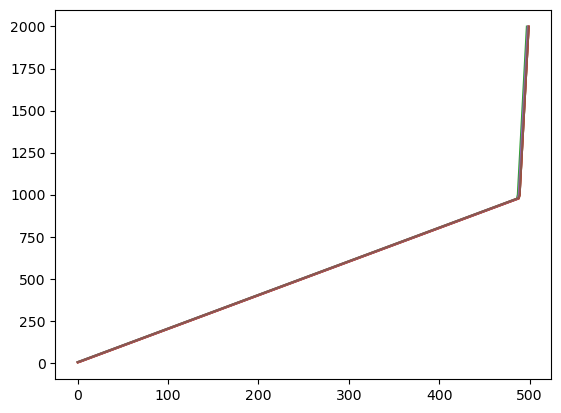

In [95]:
for n in range(11,17):
    plt.plot(prof_n['PRES_ADJUSTED'][n])

In [ ]:
core_dir = data_dir + 'Data_Products/CORE_ARGO/2026_05_12/tar_gz_files/dacs_extracted/aoml/5905372/profiles/'

core_prof = xr.load_dataset(core_dir + 'D' + wmo + '_012.nc')
core_prof['PRES_ADJUSTED'][0]

<xarray.DataArray 'PRES_ADJUSTED' (N_LEVELS: 500)> Size: 2kB
array([   2.99     ,    4.19     ,    5.9900002,    8.09     ,
          9.99     ,   11.99     ,   13.99     ,   15.99     ,
         17.99     ,   20.09     ,   22.09     ,   24.09     ,
         26.19     ,   28.09     ,   30.09     ,   32.09     ,
         33.99     ,   36.09     ,   38.09     ,   40.09     ,
         42.09     ,   44.09     ,   46.09     ,   48.09     ,
         50.09     ,   52.09     ,   54.09     ,   56.09     ,
         58.09     ,   60.09     ,   62.09     ,   64.09     ,
         66.09     ,   68.189995 ,   70.09     ,   72.09     ,
         74.09     ,   76.09     ,   78.09     ,   80.09     ,
         82.09     ,   84.09     ,   86.09     ,   88.09     ,
         90.09     ,   92.09     ,   94.09     ,   96.09     ,
         98.09     ,  100.09     ,  101.99     ,  103.99     ,
        106.09     ,  108.09     ,  110.09     ,  112.09     ,
        114.09     ,  116.09     ,  118.09     ,  120.09     ,
        122.09     ,  124.09     ,  126.09     ,  128.09     ,
        130.09     ,  132.09     ,  134.09     ,  136.09     ,
        138.09     ,  140.09     ,  142.09     ,  144.09     ,
        146.09     ,  148.09     ,  150.09     ,  152.09     ,
        154.09     ,  156.09     ,  158.09     ,  160.09     ,
...
        850.09     ,  852.09     ,  854.09     ,  856.09     ,
        858.09     ,  860.09     ,  862.09     ,  864.09     ,
        866.09     ,  868.09     ,  870.09     ,  872.09     ,
        874.09     ,  876.09     ,  878.09     ,  880.09     ,
        882.09     ,  884.09     ,  886.09     ,  888.09     ,
        890.09     ,  892.09     ,  894.09     ,  896.09     ,
        898.09     ,  900.09     ,  902.09     ,  904.09     ,
        906.09     ,  908.09     ,  910.09     ,  912.09     ,
        914.09     ,  916.09     ,  918.09     ,  920.09     ,
        922.09     ,  924.09     ,  926.09     ,  928.09     ,
        930.09     ,  932.09     ,  934.09     ,  936.09     ,
        938.09     ,  940.09     ,  942.09     ,  944.09     ,
        945.99005  ,  948.09     ,  950.09     ,  952.09     ,
        954.09     ,  956.09     ,  958.09     ,  960.09     ,
        962.09     ,  964.09     ,  966.09     ,  968.09     ,
        970.09     ,  972.09     ,  974.09     ,  976.09     ,
        977.59     ,  998.93005  , 1099.84     , 1199.45     ,
       1299.5399   , 1399.09     , 1500.1599   , 1599.19     ,
       1699.82     , 1799.5399   , 1900.1      , 1997.4099   ],
      dtype=float32)
Dimensions without coordinates: N_LEVELS
Attributes:
    long_name:       Sea water pressure, equals 0 at sea-level
    standard_name:   sea_water_pressure
    units:           decibar
    valid_min:       0.0
    valid_max:       12000.0
    C_format:        %7.1f
    FORTRAN_format:  F7.1
    resolution:      0.1

## spike example

In [24]:

# file = '6901182_Sprof_flags_mode_only.nc'
file = '5904844_Sprof_flags_mode_only.nc'

argo_n = xr.load_dataset(processed_path+file)
argo_n


<xarray.Dataset> Size: 36MB
Dimensions:                                      (N_PROF: 199, N_PARAM: 9,
                                                  N_CALIB: 1, N_LEVELS: 560)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/142)
    DATA_TYPE                                    object 8B b'Argo synthetic p...
    FORMAT_VERSION                               object 8B b'1.0 '
    HANDBOOK_VERSION                             object 8B b'1.2 '
    REFERENCE_DATE_TIME                          object 8B b'19500101000000'
    DATE_CREATION                                object 8B b'20241221120537'
    DATE_UPDATE                                  object 8B b'20241221120537'
    ...                                           ...
    DOXY_profile_mode                            (N_PROF) float64 2kB 2.0 ......
    CHLA_profile_mode                            (N_PROF) float64 2kB 1.0 ......
    CHLA_FLUORESCENCE_profile_mode               (N_PROF) float64 2kB 1.0 ......
    BBP700_profile_mode                          (N_PROF) float64 2kB 1.0 ......
    PH_IN_SITU_TOTAL_profile_mode                (N_PROF) float64 2kB 2.0 ......
    NITRATE_profile_mode                         (N_PROF) float64 2kB 2.0 ......
Attributes:
    title:                Argo float vertical profile
    institution:          AOML
    source:               Argo float
    history:              2024-12-21T12:05:37Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

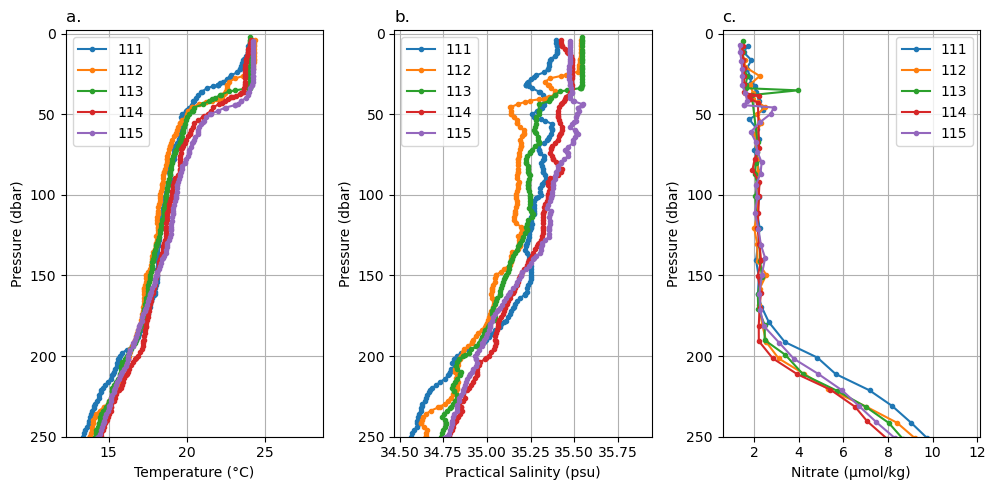

In [25]:
profile_range = np.arange(111, 116)
pressure_lims = [250, -2]

# plot profiles and time series
variables = ['TEMP', 'PSAL', 'NITRATE']
var_full_names = {'TEMP': 'Temperature', 'PSAL': 'Practical Salinity', 'DOXY': 'Dissolved Oxygen', 'NITRATE': 'Nitrate'}
units = {'TEMP': '°C', 'PSAL': 'psu', 'DOXY': 'µmol/kg', 'NITRATE': 'µmol/kg'}
var_type = '_ADJUSTED_BGCArgoPlus'
fig = plt.figure(figsize=(10, 5))


filename = 'Spike_Obs_Example_Float_' + file.split('_')[0] + '_' + plot_ver
plot_count = 0

for i, var in enumerate(variables):
    plot_count += 1
    min_val = 1000
    max_val = -1000
    ax1 = plt.subplot(1, 3, i+1)
    for prof in profile_range:
        # remove nans before plotting:
        data_p = argo_n[var + var_type].isel(N_PROF=prof)
        pres = argo_n['PRES' + var_type].isel(N_PROF=prof)
        msk = np.isfinite(data_p) & np.isfinite(pres)
        ax1.plot(data_p[msk], pres[msk], marker='.', label=f'{prof}')
        min_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
        max_val_n = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
        if min_val_n < min_val:
            min_val = min_val_n
        if max_val_n > max_val:
            max_val = max_val_n
    ax1.invert_yaxis()
    if plot_count==1:
        ax1.set_title('a.', loc='left')
    elif plot_count==2:
        ax1.set_title('b.', loc='left')
    elif plot_count==3: 
        ax1.set_title('c.', loc='left')
    ax1.set_xlabel(f'{var_full_names[var]} ({units[var]})')
    ax1.set_ylabel('Pressure (dbar)')
    ax1.grid()
    # min_val = data_p.where(pres<=pressure_lims[0]).where(pres>=pressure_lims[1]).min().item()
    # max_val = data_p.where(pres>=pressure_lims[0]).where(pres>=pressure_lims[1]).max().item()
    max_min = [min_val - 0.1*(max_val - min_val), max_val + 0.4*(max_val - min_val)]
    ax1.set_ylim(pressure_lims)
    ax1.set_xlim(max_min)
    # if var == 'DOXY':
    #     ax1.set_xlim(278, 300)
    # elif var == 'PSAL':
    #     ax1.set_xlim(min_val, max_val)
    # elif var == 'TEMP':
    #     ax1.set_xlim(min_val, max_val)
    ax1.legend()

    # ax2 = plt.subplot(2, 3, i+4)
    # times = argo_n['JULD'].isel(N_PROF=profile_range)
    # mean_values = argo_n[var].isel(N_PROF=profile_range).mean(dim='N_LEVELS')
    # ax2.plot(times, mean_values, marker='o', linestyle='-')
    # ax2.set_title(f'{var} Time Series (Mean over Profiles)')
    # ax2.set_xlabel('Time (Julian Days)')
    # ax2.set_ylabel(f'Mean {var}')
    # ax2.grid()
plt.tight_layout()
plt.savefig(group_manuscript_figs + filename + '.png', dpi=300)
